# Gambler's ruin: Simulation vs Theory

This notebook explores the classical Gambler's Ruin problem using Monte Carlo simulation and theoretical results. 

We study a gambler who repeatedly bets one unit at a time. With probability p the gambler wins a unit, and with probability 1-p they lose a unit. The game continues until the gambler either reaches a target wealth or goes bankrupt. 

We compare the simulation results with known theoretical formulas for:
- the probability of reaching the target before ruin
- the expected duration of the game

In [1]:
import random
import numpy as np
import math
import matplotlib.pyplot as plt
target=20
start = 10
numtrials = 1000


def simulation(p,start,target):
    path = [start]
    steps = 0
    current_money = start
    while (target > current_money > 0):
        if random.uniform(0,1) > p:
            current_money -= 1
        else:
            current_money += 1
        path.append(current_money)
        steps += 1
    if current_money == 0:
        return False, steps, path
    else:
        return True, steps, path

def summary(p,start,target,numtrials):
    wins = 0
    steps_list = []
    for i in range(numtrials):
        won, steps, path = simulation(p,start,target)
        if won:
            wins += 1
        steps_list.append(steps)
    return wins/numtrials , np.mean(steps_list) , steps_list 

    
def theoretical_win_prob(p, i, N):
    if p==0.5:
        return i / N
    q = 1 - p
    r = q / p
    return (1 - r**i) / (1 - r**N)

def theoretical_mean_steps(p,i,target):
    if p==0.5:
        return i*(target - i)
    q = 1-p
    r = q/p
    return (1/(q-p))*(i-target*(1-r**i)/(1-r**target))



## One Simulated Path

Before studying statistical behaviour, we simulate a single path of the gambler's wealth. 

This illustrates the random walk of the process: wealth increases or decreases by one unit at each step until the gambler either reaches the target wealth or goes bankrupt. 

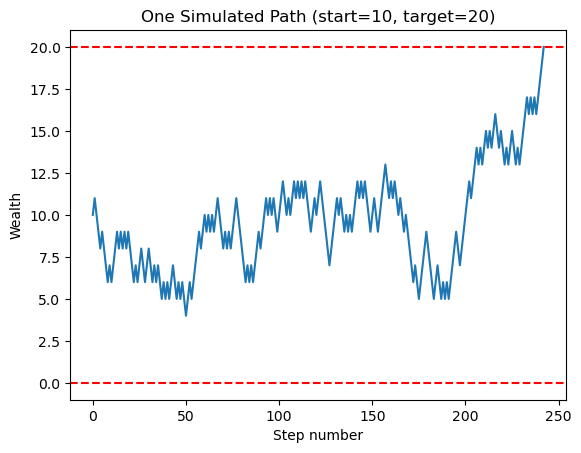

In [2]:
win, steps, path = simulation(0.5,start,target)
plt.figure()
plt.plot(path)
plt.xlabel("Step number")
plt.ylabel("Wealth")
plt.title(f"One Simulated Path (start={start}, target={target})")
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.axhline(y = target, color = 'r', linestyle = '--')
plt.show()





## Probability of Reaching the Target

We estimate the probability that the gambler reaches the target welath before ruin using Monteo Carlo simulation. 

The simulation results are compared with the theoretical formula for the Gambler's Ruin probability. 

In [3]:
ps = np.arange(0.01,1.00,0.01)


win_probs = []
mean_steps_list = []
for p in ps:
    win_prob , steps_mean , steps_list = summary(p, start, target, numtrials)
    win_probs.append(win_prob)
    mean_steps_list.append(steps_mean)

theoretical_win_probs = [theoretical_win_prob(p, start, target) for p in ps] 

theoretical_mean_steps_list = [theoretical_mean_steps(p,start,target) for p in ps]



 


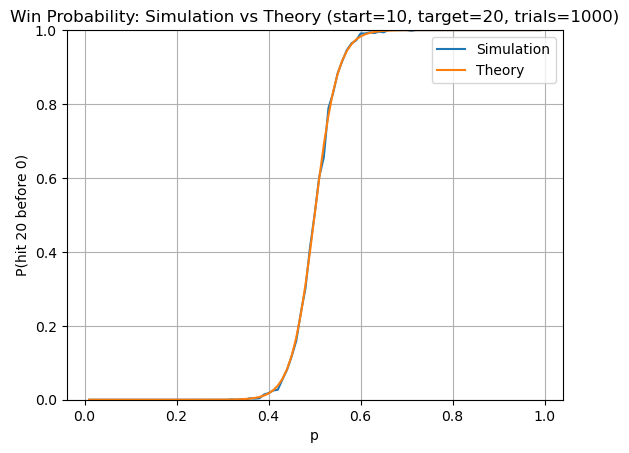

In [4]:
plt.figure()
plt.plot(ps,win_probs,label ="Simulation")
plt.plot(ps, theoretical_win_probs, label="Theory")
plt.xlabel("p")
plt.ylabel("P(hit 20 before 0)")
plt.title(f"Win Probability: Simulation vs Theory (start={start}, target={target}, trials={numtrials})")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.savefig("win_probability_simulation_vs_theory.png", dpi=300, bbox_inches="tight")
plt.show()


## Expected Duration until Absorption

We also study the expected number of steps until the game ends. 

The expected duration depends strongly on the win probability p and is largest near p = 0.5, where the random walk behaves most like a fair game. 

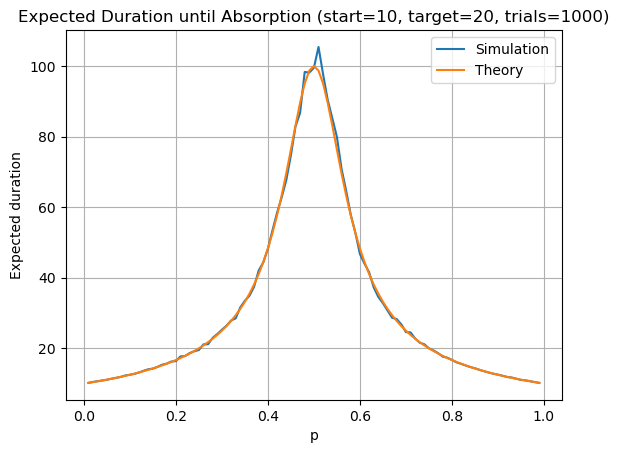

In [5]:
plt.figure()
plt.plot(ps, mean_steps_list,label ="Simulation")
plt.plot(ps, theoretical_mean_steps_list, label="Theory")
plt.xlabel("p")
plt.ylabel("Expected duration")
plt.title(f"Expected Duration until Absorption (start={start}, target={target}, trials={numtrials})")
plt.grid(True)
plt.legend()
plt.savefig("expected_duration.png", dpi=300, bbox_inches="tight")

plt.show()


## Distribution of Game Durations

Even when the expected duration is known, the actual length of individual games varies widely. 

The following histogram shows the distribution of absorption times for a fixed win probability. 

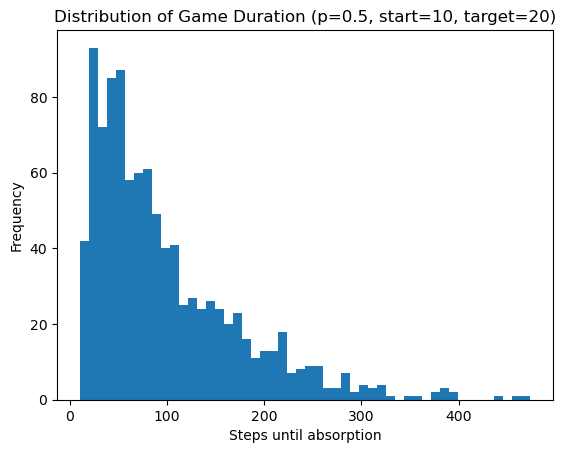

In [6]:
win_prob , steps_mean, steps_list = summary(0.5,start,target,numtrials)
plt.figure()
plt.hist(steps_list, bins = 50)
plt.xlabel("Steps until absorption")
plt.ylabel("Frequency")
plt.title(f"Distribution of Game Duration (p=0.5, start={start}, target={target})")
plt.show()



## Heatmap of Win Probability

The probability of reaching the target depends on both the starting wealth and the win probability. 

The heatmap below shows the theoretical probability of reaching the target for different starting wealth values and win probabilities. 

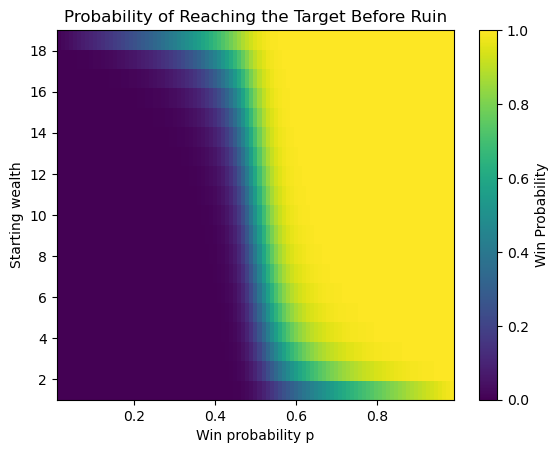

In [7]:
target = 20
start_wealth= list(range(1,target))

heatmap_data = []

for wealth in start_wealth:
    row = []
    for p in ps:
        value = theoretical_win_prob(p,wealth,target)
        row.append(value)
    heatmap_data.append(row)

heatmap_data = np.array(heatmap_data)

plt.figure()

plt.imshow(
    heatmap_data, 
    aspect='auto', 
    origin = 'lower',
    extent = [ps[0] , ps[-1] , start_wealth[0] , start_wealth[-1]]
)

plt.xlabel("Win probability p")
plt.ylabel("Starting wealth")
plt.title("Probability of Reaching the Target Before Ruin")
cbar = plt.colorbar()
cbar.set_label("Win Probability")
plt.savefig("win_probability_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Discussion 

The simulation results closely match the theoretical formulas for both win probability and expected duration. 

This example illustrates how Monte Carlo simulation can be used to explore stochastic processes and verify theoretical results for random walks and absorbing Markov chains. 